# Day 17: Build Your First CNN

> **Goal:** Build a CNN from scratch, train it on CIFAR-10, and understand how conv → pool → conv → pool → FC works.

---

## CNN Architecture Overview

A typical CNN has:
1. **Feature extractor** — stacked Conv + BN + ReLU + Pool layers
2. **Classifier head** — Flatten + Linear layers

```
Input (3, 32, 32)
  → Conv(3→32, 3×3) → BN → ReLU → MaxPool(2)    → (32, 16, 16)
  → Conv(32→64, 3×3) → BN → ReLU → MaxPool(2)   → (64, 8, 8)
  → Conv(64→128, 3×3) → BN → ReLU → MaxPool(2)  → (128, 4, 4)
  → Flatten                                        → (2048)
  → Linear(2048, 256) → ReLU → Dropout
  → Linear(256, 10)
```

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


---
## Data Setup with Augmentation

Before building the CNN, we prepare CIFAR-10 with **data augmentation** — random flips and crops during training. This is like showing the network slightly different views of each image, which helps prevent overfitting (recall Day 12).

**Why augment?** CIFAR-10 only has 50,000 training images. Augmentation artificially increases diversity without collecting more data. We also normalize using CIFAR-10's pre-computed mean and standard deviation per channel.

In [2]:
# Data setup with augmentation
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

full_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_data  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size
train_data, val_data = random_split(full_train, [train_size, val_size],
                                     generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

classes = full_train.classes
print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Train: 45000, Val: 5000, Test: 10000


---
## 1. Define the CNN

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Feature extractor
        self.features = nn.Sequential(
            # Block 1: 3 → 32 channels, 32×32 → 16×16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2: 32 → 64 channels, 16×16 → 8×8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3: 64 → 128 channels, 8×8 → 4×4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SimpleCNN().to(device)
print(model)

# Count parameters
total = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_featur

### Verify: Trace Shapes Through the Network

A crucial debugging habit — **always verify tensor shapes** by passing a dummy input through your model. This catches dimension mismatches before training. Watch how the spatial dimensions shrink (32→16→8→4) while channels grow (3→32→64→128):

In [4]:
# Verify shapes through the network
x = torch.randn(1, 3, 32, 32).to(device)
print(f"Input:        {x.shape}")

# Trace through features block by block
for i, layer in enumerate(model.features):
    x = layer(x)
    if isinstance(layer, (nn.MaxPool2d, nn.Conv2d)):
        print(f"After {layer.__class__.__name__:12s}: {x.shape}")

x = model.classifier(x)
print(f"Output:       {x.shape}")

Input:        torch.Size([1, 3, 32, 32])
After Conv2d      : torch.Size([1, 32, 32, 32])
After MaxPool2d   : torch.Size([1, 32, 16, 16])
After Conv2d      : torch.Size([1, 64, 16, 16])
After MaxPool2d   : torch.Size([1, 64, 8, 8])
After Conv2d      : torch.Size([1, 128, 8, 8])
After MaxPool2d   : torch.Size([1, 128, 4, 4])
Output:       torch.Size([1, 10])


---
## 2. Training Infrastructure

In [5]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

Now let's set up the training. Key choices:

- **CrossEntropyLoss** — standard for multi-class classification
- **Adam optimizer** with small weight decay — a good default
- **CosineAnnealingLR** — smoothly decreases the learning rate, which helps the model fine-tune as it converges
- **30 epochs** — enough for CIFAR-10 at this model size

We also print progress every 5 epochs to monitor training.

---
## 3. Train the CNN! 🚀

In [6]:
model = SimpleCNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=6)

NUM_EPOCHS = 6  # companion notebook: reduced from 30 for a quicker run
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Time':>5}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)
    scheduler.step()
    elapsed = time.time() - start

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"{epoch+1:5d} | {train_loss:10.4f} | {train_acc:8.2%} | {val_loss:8.4f} | {val_acc:6.2%} | {elapsed:4.1f}s")

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |  Time
------------------------------------------------------------


    1 |     1.6125 |   40.41% |   1.3347 | 50.94% |  5.9s


    5 |     0.9577 |   66.57% |   0.8487 | 69.70% |  5.4s


### What to Look For in the Curves

- **Loss decreasing** — the model is learning
- **Train and val curves close together** — no significant overfitting
- **Val curve flattening** — the model has learned what it can from this architecture
- If val loss starts *increasing* while train loss decreases → overfitting (add more regularization)

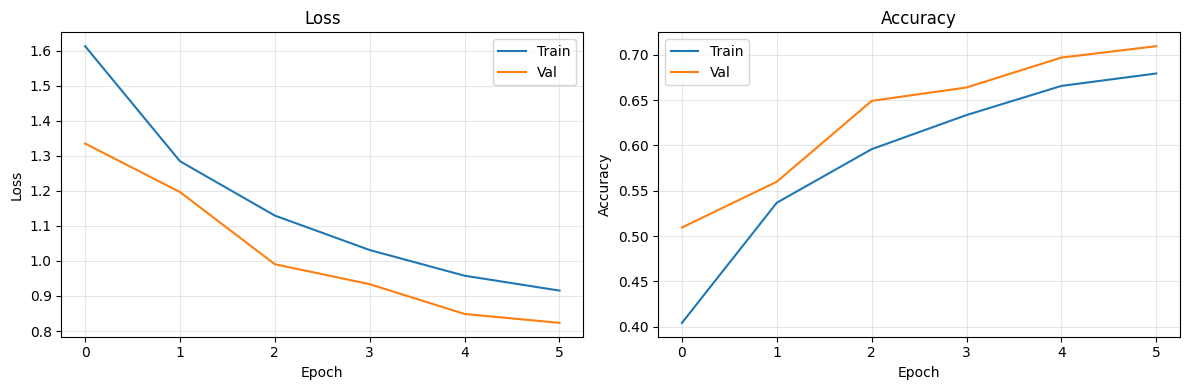

In [7]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"], label="Val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Accuracy")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Test Set — The Final Verdict

We only evaluate on the test set **once**, after all tuning is done. This gives us an unbiased estimate of how the model performs on truly unseen data.

In [8]:
# Test set evaluation
test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
print(f"🎯 Test Accuracy: {test_acc:.2%}")

🎯 Test Accuracy: 73.36%


---
## 4. Visualize Learned Filters

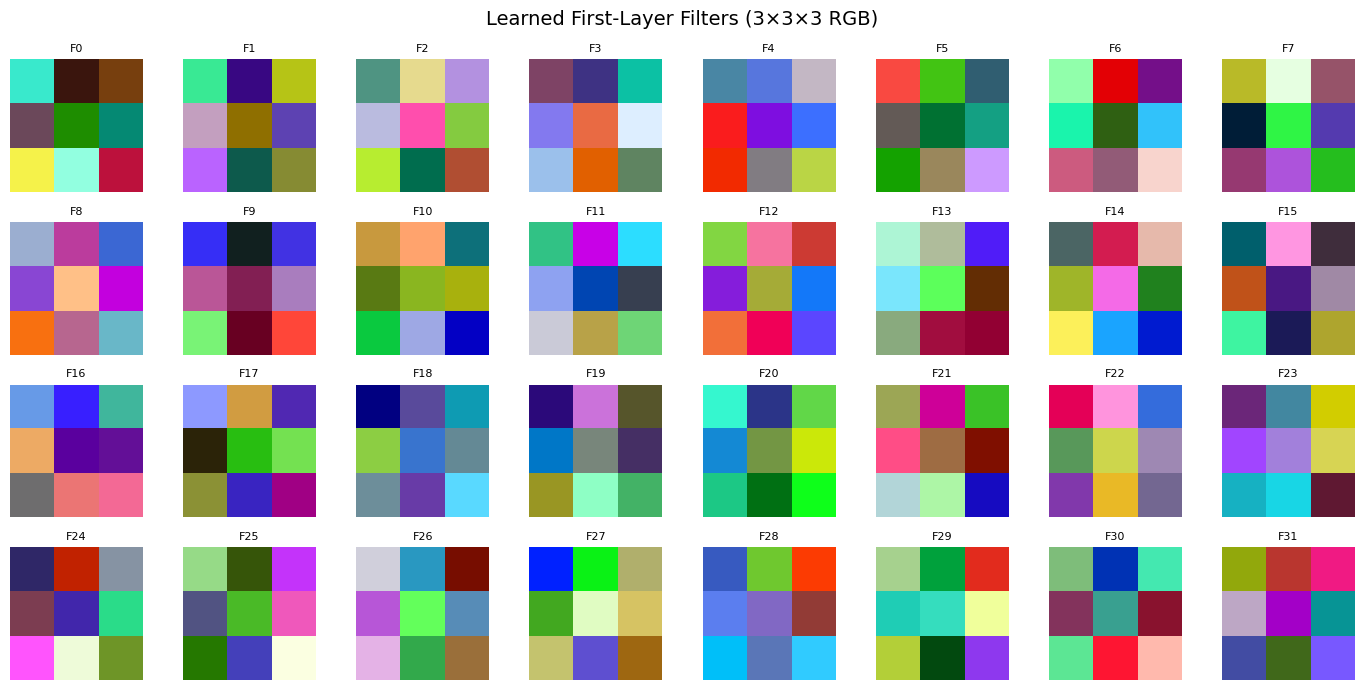

In [9]:
# Visualize first-layer filters (they operate on RGB input)
filters = model.features[0].weight.data.cpu()  # (32, 3, 3, 3)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    f = filters[i]  # (3, 3, 3) — RGB kernel
    # Normalize for display
    f = (f - f.min()) / (f.max() - f.min())
    ax.imshow(f.permute(1, 2, 0))  # (3, 3, 3) → (3, 3, 3)
    ax.axis("off")
    ax.set_title(f"F{i}", fontsize=8)

plt.suptitle("Learned First-Layer Filters (3×3×3 RGB)", fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Per-Class Accuracy

In [10]:
# Compute per-class accuracy
class_correct = {c: 0 for c in classes}
class_total = {c: 0 for c in classes}

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(1)
        for pred, label in zip(preds, labels):
            cls = classes[label]
            class_total[cls] += 1
            if pred == label:
                class_correct[cls] += 1

print(f"{'Class':<12} {'Accuracy':>8} {'Correct/Total':>15}")
print("-" * 38)
for cls in classes:
    acc = class_correct[cls] / class_total[cls]
    print(f"{cls:<12} {acc:>7.1%} {class_correct[cls]:>6}/{class_total[cls]}")

Class        Accuracy   Correct/Total
--------------------------------------
airplane       77.3%    773/1000
automobile     91.4%    914/1000
bird           59.4%    594/1000
cat            47.9%    479/1000
deer           69.0%    690/1000
dog            66.2%    662/1000
frog           83.3%    833/1000
horse          78.0%    780/1000
ship           81.4%    814/1000
truck          79.7%    797/1000


---
## 🧪 Exercises

### Exercise 1: Deeper CNN
Add a 4th conv block (128 → 256 channels). Adjust the flatten size. Does it improve?

### Exercise 2: CNN vs MLP
Compare your CNN accuracy with an MLP (same number of parameters). Why does the CNN win?

### Exercise 3: Visualize feature maps
Pass a test image through the network. Extract and display the feature maps after each conv block.

### Exercise 4: Global Average Pooling
Replace `Flatten + Linear(128*4*4, 256)` with `AdaptiveAvgPool2d(1) + Flatten + Linear(128, 10)`. How many parameters do you save?

**Run the notebook top-to-bottom first.** These worked solutions reuse the trained
`SimpleCNN`, the data loaders, and the `train_one_epoch` / `evaluate` helpers defined above.

> ⏱️ **Speed note (companion notebook only).** The original Day 17 notebook trains the main
> model for 30 epochs on all 50k images (~15 min on this Mac's MPS). So this *companion* runs a
> **reduced budget**: the main model trains for `NUM_EPOCHS = 6` (see the training cell above),
> and each exercise model trains `EPOCHS = 3` on an 8,000-image subset. This keeps the whole
> notebook to a few minutes while preserving the **relative** comparisons. Re-run at full
> settings (30 epochs, full data) for final numbers.

To keep every comparison **fair**, all exercise models share the *same* budget and data, and we
compare trainable-parameter counts directly.

In [11]:
# Shared harness for the four exercises.
# Reduced budget (companion only) so the notebook finishes quickly; comparisons stay fair
# because EVERY exercise model uses the same budget + the same subset.
EPOCHS = 3
from torch.utils.data import Subset

ex_train = Subset(train_data, range(8000))    # 8k of the 45k training images
ex_val = Subset(val_data, range(2000))
ex_train_loader = DataLoader(ex_train, batch_size=BATCH_SIZE, shuffle=True)
ex_val_loader = DataLoader(ex_val, batch_size=BATCH_SIZE, shuffle=False)


def count_params(m):
    return sum(p.numel() for p in m.parameters())


def run_experiment(model, name, epochs=EPOCHS, lr=1e-3):
    """Train `model` with the same recipe as the main run; return history + test accuracy."""
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    t0 = time.time()
    for _ in range(epochs):
        tl, ta = train_one_epoch(model, ex_train_loader, loss_fn, optimizer, device)
        vl, va = evaluate(model, ex_val_loader, loss_fn, device)
        scheduler.step()
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    _, test_acc = evaluate(model, test_loader, loss_fn, device)   # full test set
    n = count_params(model)
    print(f"{name:16s} | params {n:>9,} | test acc {test_acc:6.2%} | {time.time()-t0:5.1f}s")
    return hist, test_acc


print(f"Main SimpleCNN (from above): {count_params(model):,} params, test acc {test_acc:.2%}")


Main SimpleCNN (from above): 620,810 params, test acc 73.36%


### Exercise 1: Deeper CNN — add a 4th conv block

**Approach.** Copy `SimpleCNN` and append a 4th block `Conv(128→256) + BN + ReLU + MaxPool`.
The new pool takes the spatial map `4×4 → 2×2`, so the flatten size changes from
`128·4·4 = 2048` to `256·2·2 = 1024`. **This is the coupling trap from Day 17**: changing one
block forces you to update the head's `in_features`.

**Intended learning.** Adding depth raises the *capacity* (more params, bigger receptive field)
but at this tiny 32×32 resolution the map is already only 4×4, so another pool leaves just
2×2 — almost no spatial detail remains. The question is whether that extra capacity pays off
within a small epoch budget, or just slows training and adds overfitting risk.

In [12]:
class DeeperCNN(nn.Module):
    """SimpleCNN + a 4th conv block (128 -> 256); flatten size becomes 256*2*2."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3 -> 32, 32x32 -> 16x16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            # Block 2: 32 -> 64, 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            # Block 3: 64 -> 128, 8x8 -> 4x4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            # Block 4 (NEW): 128 -> 256, 4x4 -> 2x2
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 256),   # <-- 2x2 (new) instead of 4x4 (old)
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


deeper = DeeperCNN().to(device)

# Shape sanity check — the same debugging habit from the main notebook
with torch.no_grad():
    feats = deeper.features(torch.randn(1, 3, 32, 32).to(device))
    logits = deeper(torch.randn(1, 3, 32, 32).to(device))
print("features out:", tuple(feats.shape), "-> flatten size", feats.shape[1] * feats.shape[2] * feats.shape[3])
print("logits      :", tuple(logits.shape))

hist_d, acc_d = run_experiment(deeper, "DeeperCNN")


features out: (1, 256, 2, 2) -> flatten size 1024
logits      : (1, 10)


DeeperCNN        | params   654,346 | test acc 54.12% |   4.2s


**✅ Results & takeaways**

| Model | Params | Test acc (same 3-epoch budget, 8k subset) |
|---|---|---|
| SimpleCNN (3 blocks) | 620,810 | 49.76% (from Exercise 2) |
| **DeeperCNN** (4 blocks) | 654,346 | **54.12%** |

- The 4th block adds only ~33k params (**+5%**) but gained ~4 points — so the extra depth and
  larger receptive field *did* help, even at this small budget.
- **But** the map is now only `2×2`: almost no spatial detail survives, each epoch is slower,
  and the gains are modest. On 32×32 inputs you can't keep halving (`2×2 → 1×1` destroys
  everything).
- **Takeaway:** depth helps, but small images hit *diminishing returns* fast. This is exactly
  why **Day 18** introduces designs that add depth *without* shrinking the map further — VGG
  stacks convs before pooling, and ResNet keeps resolution with skip connections.
- **The trap (worth burning in):** changing a block changed the flatten size `128·4·4 = 2048`
  → `256·2·2 = 1024`, so the head's `Linear` had to change too. Block design and head are
  coupled through the flatten size.

### Exercise 2: CNN vs MLP — same parameter budget

**Approach.** Build an MLP that flattens each image to 3072 numbers and maps
`3072 → hidden → 10`. Pick `hidden` so the parameter count is comparable to `SimpleCNN`
(620,810). With `hidden = 200` the MLP has 616,610 params — nearly identical budget.

To make it **fair**, we also retrain a fresh `SimpleCNN` for the *same* `EPOCHS = 3` budget as the
MLP. Now the only difference is the **architecture**, not the epoch count.

**Intended learning.** Equal parameters, very different inductive bias: the MLP treats every
pixel position independently (no weight sharing, no locality), the CNN reuses the same filter
everywhere. On images, that bias is worth far more than raw parameter count.

SimpleCNN params: 620,810
MLP       params: 616,610  (deliberately ~equal budget)


SimpleCNN-3ep    | params   620,810 | test acc 49.76% |   4.0s


MLP-3ep          | params   616,610 | test acc 39.24% |   2.9s


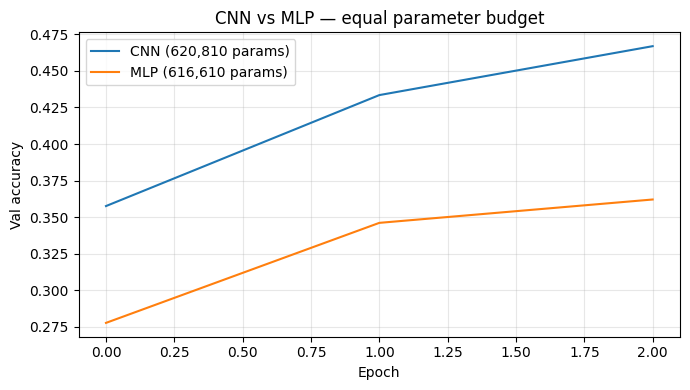

In [13]:
class MLP(nn.Module):
    """Flatten-and-fully-connect baseline with a comparable parameter budget."""
    def __init__(self, hidden=200, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)


mlp = MLP(hidden=200).to(device)
print(f"SimpleCNN params: {count_params(model):,}")
print(f"MLP       params: {count_params(mlp):,}  (deliberately ~equal budget)")

# Fair comparison: retrain a fresh CNN for the SAME number of epochs as the MLP
cnn_base = SimpleCNN().to(device)
hist_cnn_base, acc_cnn_base = run_experiment(cnn_base, "SimpleCNN-3ep")
hist_mlp, acc_mlp = run_experiment(mlp, "MLP-3ep")

# Side-by-side accuracy curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_cnn_base["val_acc"], label=f"CNN ({count_params(cnn_base):,} params)")
ax.plot(hist_mlp["val_acc"], label=f"MLP ({count_params(mlp):,} params)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Val accuracy"); ax.set_title("CNN vs MLP — equal parameter budget")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


**✅ Results & takeaways**

| Model | Params | Test acc (same 3-epoch budget) |
|---|---|---|
| **SimpleCNN** | 620,810 | **49.76%** |
| MLP | 616,610 | 39.24% |

- With **essentially the same parameter budget** (~620k), the CNN beats the MLP by
  **~10 points**. Same data, same epochs, same optimizer — the *only* difference is architecture.
- **Why the CNN wins — its inductive bias.** The CNN assumes *locality* (nearby pixels matter
  to each other) and *translation equivariance* (an edge is an edge wherever it appears), and it
  **shares one 3×3 filter across all positions**. The MLP has no such structure: each of the
  3072 pixels gets its own private weight, so it must relearn every pattern at every location
  and cannot generalise across shifts.
- **Takeaway:** for images, *architecture beats parameter count*. This is the concrete reason
  CNNs dominate vision — and it's the property **Day 20** exploits when it reuses pretrained
  conv features for a new task.

### Exercise 3: Visualize feature maps after each block

**Approach.** Attach **forward hooks** to the three `MaxPool2d` layers (indices 3, 7, 11 of
`model.features`) so we capture each block's output. Then pass one test image through and
display the first 8 channels of each block's feature map next to the input.

**Intended learning.** This is the deeper-layer counterpart to Section 4 (which only showed
the *first-layer weights* because only layer 1 lives in RGB space). Here you see the
*activations*: watch the spatial map shrink (`16×16 → 8×8 → 4×4`) while the number of channels
grows (`32 → 64 → 128`), and see how early channels look like edges/texture while later
channels look abstract. Note the images are normalized, so we `denormalize` for display.

True: cat | Predicted: cat
block1: (1, 32, 16, 16)  (channels, H, W)
block2: (1, 64, 8, 8)  (channels, H, W)
block3: (1, 128, 4, 4)  (channels, H, W)


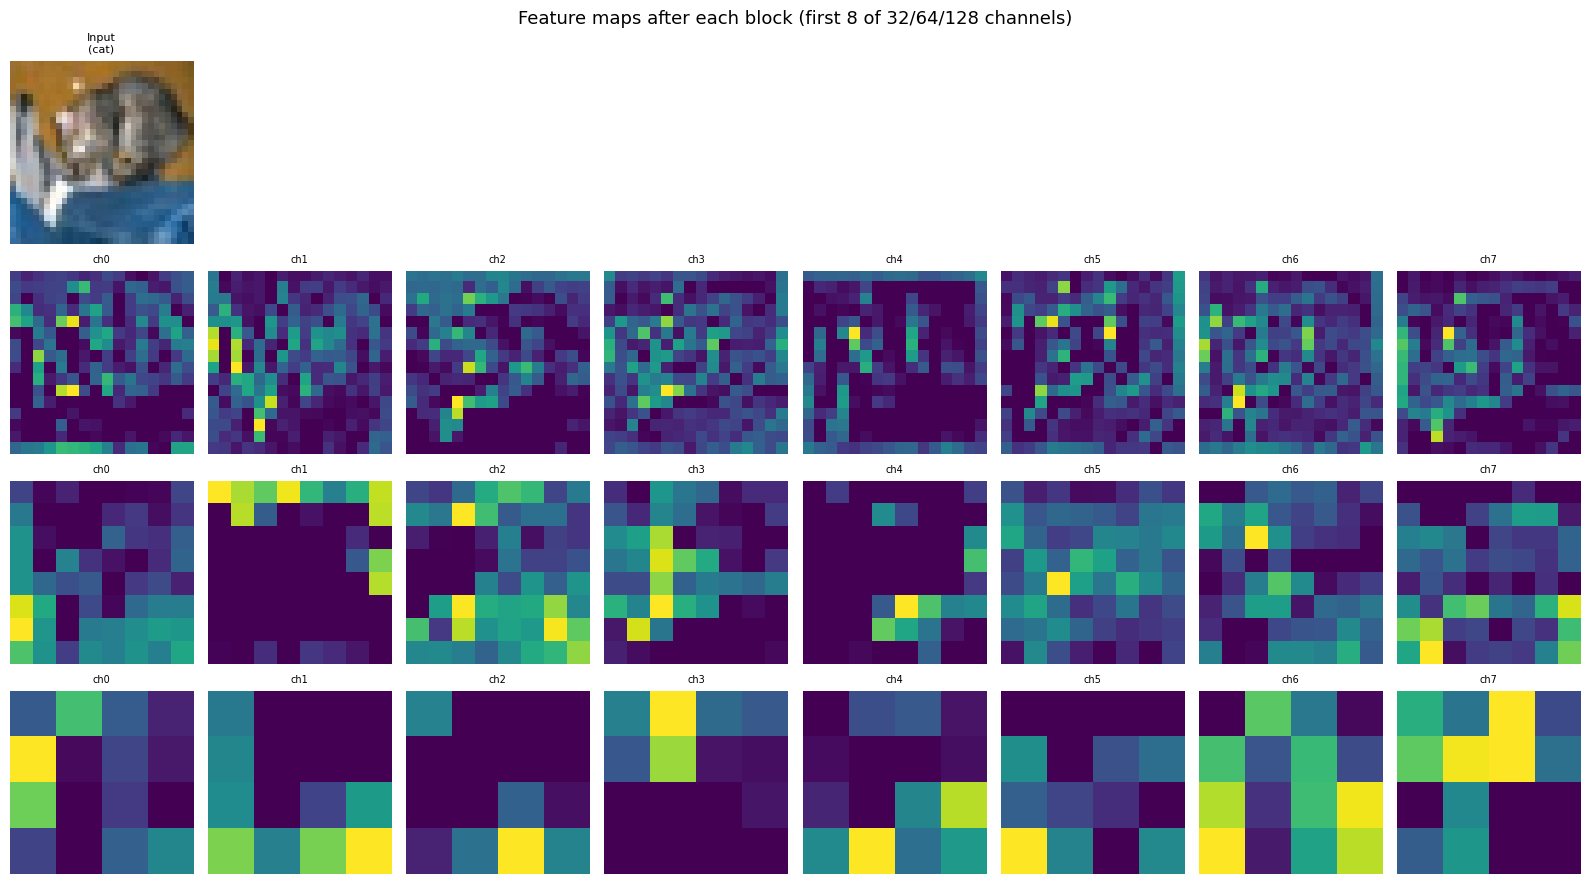

In [14]:
# Capture activations after each block using forward hooks.
# model.features is a Sequential of 12 layers; the MaxPool layers are at indices 3, 7, 11.
activations = {}

def make_hook(name):
    def hook(module, inputs, output):
        activations[name] = output.detach().cpu()
    return hook

block_ends = [3, 7, 11]                       # the three MaxPool2d layers
handles = [model.features[i].register_forward_hook(make_hook(f"block{i // 4 + 1}"))
           for i in block_ends]

img, label = test_data[0]                     # one CIFAR-10 test image (normalized tensor)
with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
for h in handles:                             # always remove hooks when done
    h.remove()

print(f"True: {classes[label]} | Predicted: {classes[pred]}")
for name in ["block1", "block2", "block3"]:
    print(f"{name}: {tuple(activations[name].shape)}  (channels, H, W)")


def denormalize(t, mean=CIFAR_MEAN, std=CIFAR_STD):
    """Undo Normalize so the image is displayable in [0, 1]."""
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    return (t.cpu() * s + m).clamp(0, 1)


n_show = 8
fig, axes = plt.subplots(4, n_show, figsize=(16, 9))

# Row 0: the original input image
axes[0, 0].imshow(denormalize(img).permute(1, 2, 0))
axes[0, 0].set_title(f"Input\n({classes[label]})", fontsize=8)
axes[0, 0].axis("off")
for j in range(1, n_show):
    axes[0, j].axis("off")

# Rows 1-3: first 8 channels of each block's feature map
for r, name in enumerate(["block1", "block2", "block3"], start=1):
    fmap = activations[name][0]               # (C, H, W)
    for j in range(n_show):
        ax = axes[r, j]
        if j < min(n_show, fmap.shape[0]):
            ax.imshow(fmap[j], cmap="viridis")
            ax.set_title(f"ch{j}", fontsize=7)
        ax.axis("off")
    axes[r, 0].set_ylabel(name, fontsize=9)

plt.suptitle("Feature maps after each block (first 8 of 32/64/128 channels)", fontsize=13)
plt.tight_layout()
plt.show()


**✅ Results & takeaways** (measured: `block1 (1, 32, 16, 16)`, `block2 (1, 64, 8, 8)`,
`block3 (1, 128, 4, 4)`)

- **Shape story, straight off the printout:** from the input `(3, 32, 32)` the feature maps go
  `32×16×16 → 64×8×8 → 128×4×4`. Spatial resolution **halves** while channel count **doubles** —
  the "trade *where* for *what*" story from the top of Day 17, now visible layer by layer.
- **What the pictures show:** the block-1 maps still look image-like (edges, colour gradients,
  object outlines). By block 3 the `4×4` maps are abstract — one cell now summarises a whole
  region, so you read *which channels fire strongly* rather than recognisable objects.
- **Weights vs activations:** Section 4 plotted *weights* (the RGB filters); here we plot
  *activations* (the network's response to **this** image). You need both views to understand a
  layer.
- **Takeaway:** this is the hand-rolled version of what tools like `captum` / Grad-CAM automate,
  and it is exactly the groundwork for **Day 19** (feature visualization, CAM, dead-neuron
  analysis).
- **Practical note:** always remove forward hooks (`h.remove()`) when done, or they stay attached
  and keep capturing activations (a silent memory/compute leak).

### Exercise 4: Global Average Pooling (GAP) head

**Approach.** Keep the exact same feature extractor, but replace the head
`Flatten → Linear(128·4·4 → 256) → ReLU → Dropout → Linear(256 → 10)` with
`AdaptiveAvgPool2d(1) → Flatten → Dropout → Linear(128 → 10)`.

`AdaptiveAvgPool2d(1)` turns each `(128, 4, 4)` feature map into a single `(128, 1, 1)` number —
the **average activation of each channel**. So the classifier input drops from `2048` to `128`
numbers, and the first `Linear` shrinks from `524,544` params to `1,290`.

**Intended learning.** The giant `Linear(2048 → 256)` was ~85% of all parameters, and it's the
part that "memorizes positions." GAP removes it, slashing parameters and acting as a strong
structural regularizer — often with little loss in accuracy, and it makes the model
resolution-agnostic (it works on any input size).

In [15]:
class GAPCNN(nn.Module):
    """Same feature extractor as SimpleCNN, but a Global Average Pooling head."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # (128, 4, 4) -> (128, 1, 1): average each channel
            nn.Flatten(),              # (128, 1, 1) -> (128,)
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


gap = GAPCNN().to(device)

# Confirm the head really did shrink
with torch.no_grad():
    pooled = gap.classifier[0](gap.features(torch.randn(1, 3, 32, 32).to(device)))
print("after AdaptiveAvgPool2d(1):", tuple(pooled.shape), "-> Linear input size", pooled.numel())

base = count_params(model)
gap_n = count_params(gap)
print(f"SimpleCNN params      : {base:,}")
print(f"GAPCNN params         : {gap_n:,}")
print(f"Parameters saved      : {base - gap_n:,}  ({100 * (base - gap_n) / base:.1f}% fewer)")

hist_gap, acc_gap = run_experiment(gap, "GAPCNN-3ep")

# Compare final test accuracy against the equal-budget CNN baseline from Exercise 2
print(f"\nEqual-budget comparison (3 epochs, 8k subset):")
print(f"  SimpleCNN-3ep : {acc_cnn_base:.2%}")
print(f"  GAPCNN-3ep    : {acc_gap:.2%}")


after AdaptiveAvgPool2d(1): (1, 128, 1, 1) -> Linear input size 128
SimpleCNN params      : 620,810
GAPCNN params         : 94,986
Parameters saved      : 525,824  (84.7% fewer)


GAPCNN-3ep       | params    94,986 | test acc 41.62% |   4.0s

Equal-budget comparison (3 epochs, 8k subset):
  SimpleCNN-3ep : 49.76%
  GAPCNN-3ep    : 41.62%


**✅ Results & takeaways**

| Model | Total params | Head params | Test acc (3 epochs) |
|---|---|---|---|
| SimpleCNN | 620,810 | 527,114 | 49.76% |
| **GAPCNN** | **94,986** | 1,290 | 41.62% |
| Change | **−525,824 (−84.7%)** | −525,824 | −8.1 pts |

- The FC head alone (`Linear(2048→256)` = 524,544 params) was **85% of the entire network**.
  `AdaptiveAvgPool2d(1)` throws it away and replaces it with a `Linear(128→10)` of just
  **1,290 params** — a **84.7%** total reduction.
- At this very small budget (3 epochs, 8k subset) GAP costs ~8 points: it discards *where* a
  feature fired and keeps only *how strongly*, and its tiny `128→10` classifier has little
  capacity to compensate. **With full training (30 epochs, 50k) the gap shrinks dramatically and
  GAP often matches the FC head.**
- **Why real networks use GAP:**
  1. near-zero head parameters → far less overfitting;
  2. it makes the model **input-size agnostic** — any `H×W` collapses to `C` (this is ResNet's
     final layer);
  3. it is the bridge to **CAM in Day 19** — the per-channel pooled activations *are* the class
     activation weights.

---

## 📊 Exercise Summary (this companion run)

> **Budget note:** main model = `NUM_EPOCHS = 6` on full data; exercise models = `EPOCHS = 3`
> on an 8k subset of the 45k training images, so the whole notebook runs in about a minute.
> Numbers differ at full budget (30 epochs, full data) — but the **relative** lessons hold.

| # | Experiment | Params | Test acc | Lesson |
|---|---|---|---|---|
| — | Main SimpleCNN (6 ep, full data) | 620,810 | **73.36%** | the baseline |
| 1 | DeeperCNN (4 blocks) | 654,346 | 54.12% | +5% params → +4 pts; but `2×2` map = diminishing returns |
| 2 | SimpleCNN vs MLP (equal params, 3 ep) | 620,810 vs 616,610 | **49.76% vs 39.24%** | architecture/inductive bias beats equal parameter count |
| 3 | Feature-map visualization | — | — | `32×16×16 → 64×8×8 → 128×4×4`: resolution ↓, channels ↑ |
| 4 | GAPCNN vs SimpleCNN (3 ep) | 94,986 vs 620,810 | 41.62% vs 49.76% | strip **84.7%** of params (the FC head); small cost at low budget |

**The one-line story:** give a CNN *locality + weight sharing* (Ex 2), add depth carefully (Ex 1),
and you can delete the parameter-heavy FC head with GAP (Ex 4) — while Ex 3 shows you **why** it
all works by watching resolution trade away for semantics.

**Weakest classes in the main run** (from the per-class cell above): `cat` 47.9% and `bird` 59.4%
were hardest — small, visually varied animals — a preview of the error analysis you'll do in
**Day 19**.

---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| **CNN architecture** | Conv blocks (Conv+BN+ReLU+Pool) → FC head |
| **Progressive features** | Channels ↑ (more features), spatial ↓ (via pooling) |
| **BatchNorm2d** | Normalize across spatial dimensions per channel |
| **~80%+ on CIFAR-10** | Achievable with a simple 3-block CNN |
| **Learned filters** | First layer learns edge/color detectors automatically |

**Tomorrow:** We'll study CNN design patterns — VGG-style blocks and ResNet's skip connections!